In [2]:
import pandas as pd

def tratar_trends(caminho_arquivo, nome_termo):
    df = pd.read_csv(caminho_arquivo, skiprows=2, encoding="utf-8")
    df.columns = ["mes", "interesse"]
    
    df["ano"] = df["mes"].str[:4].astype(int)
    df["termo"] = nome_termo
    
    # Agrega de mensal pra anual (média do ano)
    df_anual = df.groupby(["ano", "termo"])["interesse"].mean().reset_index()
    df_anual["interesse"] = df_anual["interesse"].round(2)
    
    return df_anual

df_faz_mal = tratar_trends("../data/raw/trends_vacina_faz_mal.csv", "vacina faz mal")
df_efeitos = tratar_trends("../data/raw/trends_efeitos_colaterais.csv", "efeitos colaterais vacina")

df_trends = pd.concat([df_faz_mal, df_efeitos], ignore_index=True)

print(df_trends.shape)
df_trends.head(10)

(24, 3)


,ano,termo,interesse
0,2013,vacina faz mal,3.50
1,2014,vacina faz mal,4.92
2,2015,vacina faz mal,5.33
3,2016,vacina faz mal,8.17
4,2017,vacina faz mal,9.92
5,2018,vacina faz mal,12.92
6,2019,vacina faz mal,10.75
7,2020,vacina faz mal,12.67
8,2021,vacina faz mal,54.58
9,2022,vacina faz mal,30.58


In [6]:
df_brasil = pd.read_csv("../data/processed/cobertura_vacinal_brasil.csv");

In [7]:
# Cobertura vacinal média nacional por ano
df_cobertura_nacional = (
    df_brasil.groupby("ano")["cobertura"]
    .mean()
    .reset_index()
)

# Junta com o índice de busca "vacina faz mal"
df_trends_cobertura = pd.merge(
    df_cobertura_nacional,
    df_trends[df_trends["termo"] == "vacina faz mal"][["ano", "interesse"]],
    on="ano"
)

correlacao_trends = df_trends_cobertura["interesse"].corr(df_trends_cobertura["cobertura"])
print(f"Correlação entre busca por 'vacina faz mal' e cobertura vacinal: {correlacao_trends:.3f}")

df_trends_cobertura

Correlação entre busca por 'vacina faz mal' e cobertura vacinal: -0.761


,ano,cobertura,interesse
0,2013,103.3600,3.50
1,2014,103.0800,4.92
2,2015,99.0850,5.33
3,2016,91.2300,8.17
4,2017,88.3525,9.92
5,2018,92.6425,12.92
6,2019,83.7300,10.75
7,2020,78.2000,12.67
8,2021,73.1350,54.58
9,2022,81.3100,30.58


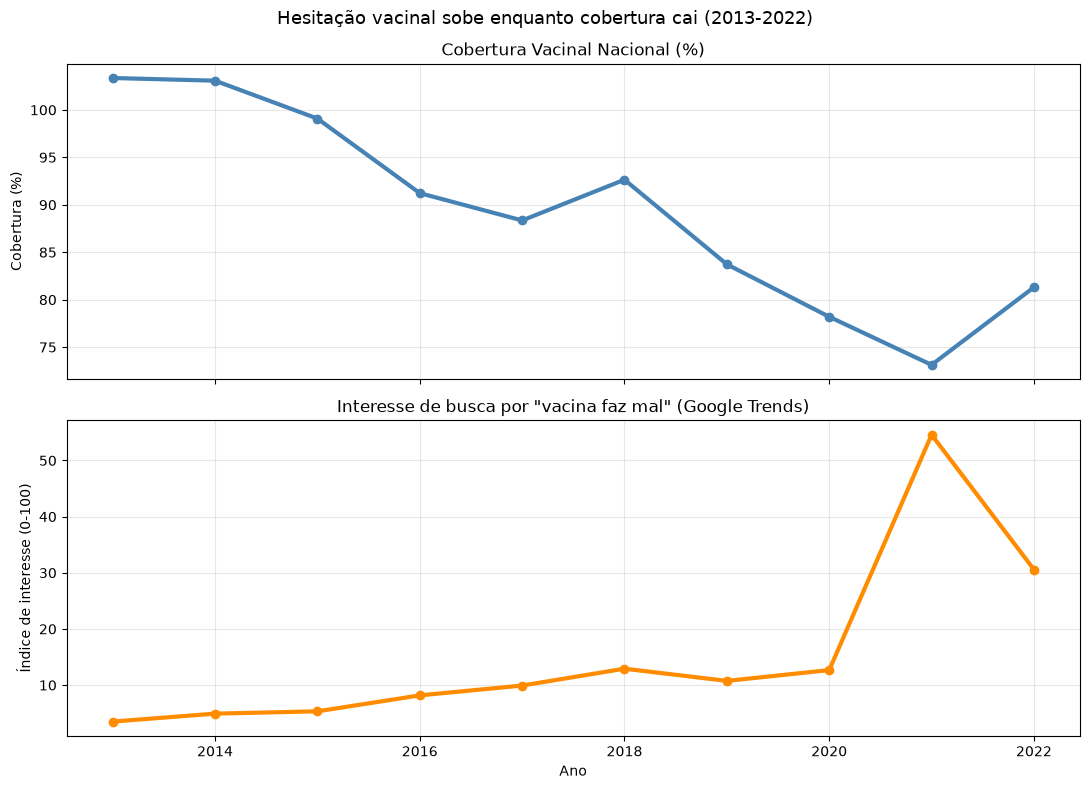

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax1.plot(df_trends_cobertura["ano"], df_trends_cobertura["cobertura"], color="steelblue", marker="o", linewidth=3)
ax1.set_title("Cobertura Vacinal Nacional (%)")
ax1.set_ylabel("Cobertura (%)")
ax1.grid(alpha=0.3)

ax2.plot(df_trends_cobertura["ano"], df_trends_cobertura["interesse"], color="darkorange", marker="o", linewidth=3)
ax2.set_title('Interesse de busca por "vacina faz mal" (Google Trends)')
ax2.set_xlabel("Ano")
ax2.set_ylabel("Índice de interesse (0-100)")
ax2.grid(alpha=0.3)

plt.suptitle("Hesitação vacinal sobe enquanto cobertura cai (2013-2022)", fontsize=13)
plt.tight_layout()
plt.savefig("../dashboard/grafico_hesitacao_vacinal.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
import statsmodels.api as sm

X = df_trends_cobertura["interesse"]
y = df_trends_cobertura["cobertura"]

X = sm.add_constant(X)  # adiciona o intercepto

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              cobertura   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     11.01
Date:                Thu, 02 Jul 2026   Prob (F-statistic):             0.0106
Time:                        17:45:42   Log-Likelihood:                -32.777
No. Observations:                  10   AIC:                             69.55
Df Residuals:                       8   BIC:                             70.16
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.1327      3.249     29.895      0.0